# Task: Sampling Theorem

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 1 - Data and Domain

### Use Case

In the context of Swiss railway infrastructure monitoring, continuous-time vertical bogie vibration signals are generated by wheel-rail interaction and acquired by onboard accelerometers to detect early defect signatures before safety-critical failures occur. These digital vibration signals are used by SBB maintenance and safety teams to support predictive maintenance decisions, including whether a wheelset requires immediate inspection or can remain in service. This use case is particularly relevant for Switzerland because high tunnel density, alpine routes, and strict safety expectations require reliable early-warning diagnostics under regular passenger operation.

### Problem Statement

This project addresses the problem of selecting an appropriate sampling rate for accelerometer-based bogie vibration monitoring in the Swiss rail context. If the sampling rate is too low, aliasing can mask or shift defect-related frequency content and cause missed early-warning signals; if the sampling rate is unnecessarily high, storage and transmission overhead increase without proportional diagnostic benefit. Preserving diagnostically relevant frequency components is essential for reliable wheel-defect detection and risk reduction in tunnel operations.

### Experimental Objective

The objective of this project is to investigate how sampling-rate choices influence the preservation of informative vibration features within a fixed 0.5 s analysis window. The goal is to determine which reduced sampling conditions still retain sufficient short-time information for practical predictive maintenance decisions in the Swiss SBB use case.

### Data Definition, Source, and Visualization

The selected signal is a one-dimensional synthetic vertical bogie vibration measurement representing train operation at 80 km/h, expressed in normalised acceleration units [a.u.]. The generated signal has duration 60 seconds at 575 Hz, so it contains 34,500 samples. It includes baseline vibration dynamics, periodic defect-like impulses, and light additive noise to emulate a realistic monitoring scenario with controlled degradation signatures. The data are generated with `mc1/generate_synthetic_signal.py` and loaded from `data/synthetic_defect_signal.npy`. This controlled synthetic source is appropriate for sampling-theorem experiments because it enables reproducible comparison of downsampling effects while preserving known defect-related structure.

Signal path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/synthetic_defect_signal.npy
Signal shape: (34500,), dtype: float64
Loaded event timestamps: 461
Events in first 1.0 s: 7
Signal mean=0.018972, std=0.126133, min=-0.279342, max=0.626337


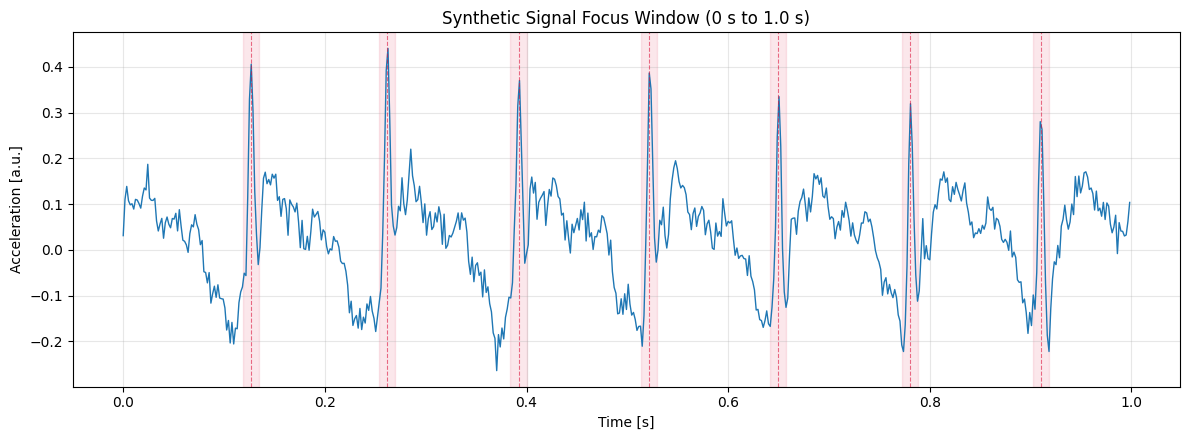

In [50]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
FOCUS_WINDOW_SECONDS = 1
EVENT_MARKER_HALF_WIDTH_S = 0.008
DEFECT_CUTOUT_PRE_S = 0.03
DEFECT_CUTOUT_POST_S = 0.05

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "synthetic_defect_signal.npy"
event_path = project_root / "data" / "synthetic_defect_signal_event_times.npy"

x_full = np.load(x_path).astype(np.float64)
event_times = np.load(event_path).astype(np.float64) if event_path.exists() else np.array([], dtype=np.float64)

assert x_full.ndim == 1, "Expected a 1D synthetic signal."
assert x_full.size == FS_HZ * DURATION_SECONDS, "Unexpected signal length for 60 s at 575 Hz."

x_ref = x_full
time_s = np.arange(x_ref.size) / FS_HZ
event_times_focus = event_times[(event_times >= 0.0) & (event_times < FOCUS_WINDOW_SECONDS)]

print(f"Signal path: {x_path}")
print(f"Signal shape: {x_ref.shape}, dtype: {x_ref.dtype}")
print(f"Loaded event timestamps: {event_times.size}")
print(f"Events in first {FOCUS_WINDOW_SECONDS:.1f} s: {event_times_focus.size}")
print(
    f"Signal mean={x_ref.mean():.6f}, std={x_ref.std():.6f}, "
    f"min={x_ref.min():.6f}, max={x_ref.max():.6f}"
)

zoom_mask = (time_s >= 0) & (time_s < FOCUS_WINDOW_SECONDS)

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.plot(time_s[zoom_mask], x_ref[zoom_mask], linewidth=1.0, label="signal")

for t_evt in event_times_focus:
    ax.axvspan(
        max(0.0, t_evt - EVENT_MARKER_HALF_WIDTH_S),
        min(FOCUS_WINDOW_SECONDS, t_evt + EVENT_MARKER_HALF_WIDTH_S),
        color="crimson",
        alpha=0.10,
    )
    ax.axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(f"Synthetic Signal Focus Window (0 s to {FOCUS_WINDOW_SECONDS:.1f} s)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [a.u.]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations**:
The visualization focuses on the first 0.5 seconds and reveals clear short-time oscillatory structure around the local baseline, including rapid amplitude changes that are harder to compare on long windows. This focused segment is used as the primary analysis window because it makes reconstruction differences directly interpretable for the sampling-rate experiment in the SBB predictive maintenance use case.

### Transition to Method Design
The domain context, signal source, and baseline visualization are now established. The next sections formalize the sampling-theorem assumptions and define the exact parameter sweep used for reproducible implementation and evaluation.

## Day 2 - Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the Nyquist-Shannon sampling principle to railway bogie vibration monitoring for Swiss predictive maintenance. The principle assumes that the relevant signal content is sufficiently band-limited and that anti-alias filtering is applied before decimation; under these conditions, sampling at or above twice the highest relevant frequency preserves information for analysis. A controlled downsampling-and-reconstruction workflow is selected because it operationalizes this principle and allows direct measurement of information loss in a use-case-relevant way. If assumptions are violated, aliasing and distortion can mislead defect-related interpretation.

### Parameter Definition and Mathematical Specification

The reference signal is sampled at $f_s=575\,\mathrm{Hz}$, and the analysis window is fixed to $T_w=0.5\,\mathrm{s}$ for all experiments. This gives a window sample count of $N_w=f_s\cdot T_w=575\cdot0.5\approx288$ samples, with sampling interval $\Delta t=1/f_s\approx1.739\,\mathrm{ms}$. The reduced experiment set uses target rates $f_s'\in\{384,192,48\}\,\mathrm{Hz}$ with linear reconstruction back to the same 0.5 s reference grid. These rates are selected as a structured sweep: 384 Hz is a mild reduction (about 33% fewer samples than 575 Hz), 192 Hz is a medium reduction (about 67% fewer samples), and 48 Hz is a strong stress-test reduction (about 92% fewer samples). In this domain, lowering $f_s'$ reduces telemetry load, while rising window-based reconstruction error indicates potential loss of defect-relevant short-time vibration detail.

### Experimental Design for Next Days

The baseline configuration is the original sampled signal at $575\,\mathrm{Hz}$, evaluated on a fixed 0.5 s reference window. The reduced comparison set varies only target sampling rate with linear reconstruction, using $f_s'\in\{575,384,192,48\}\,\mathrm{Hz}$. This specific set is used to test three practical operating regimes: near-baseline fidelity (384 Hz), balanced compression (192 Hz), and aggressive compression stress test (48 Hz). All metrics and visual comparisons are computed on the same first 0.5 s segment to keep the experiment internally consistent and directly comparable. It is theoretically expected that decreasing $f_s'$ increases window-level reconstruction error, with strongest degradation at $48\,\mathrm{Hz}$ and intermediate behavior at $384\,\mathrm{Hz}$.

### Methodological Limitations and Risk Factors

This approach assumes that one selected row is representative and that relevant vibration features are sufficiently band-limited, which may be violated under transient events, non-stationarity, or changing track conditions. The method is most reliable when noise and operational variability are moderate, but can become misleading when low-frequency drift or high-frequency impulsive components dominate. In this railway use case, primary risks are row-selection bias and aliasing-induced feature loss, potentially leading to underestimation of maintenance urgency.

## Day 3 - Implementation

In [51]:
import numpy as np
import pandas as pd


def load_focus_window() -> np.ndarray:
    assert x_full.size == FS_HZ * DURATION_SECONDS

    focus_samples = max(1, int(FS_HZ * FOCUS_WINDOW_SECONDS))
    return x_full[:focus_samples]


def reconstruct_with_linear_interp(signal: np.ndarray, fs_in: int, fs_target: int) -> np.ndarray:
    target_count = int(round(signal.size * fs_target / fs_in))
    t_ref = np.arange(signal.size) / fs_in
    t_down = np.linspace(0.0, t_ref[-1], target_count)
    downsampled = np.interp(t_down, t_ref, signal)
    return np.interp(t_ref, t_down, downsampled)


def reconstruct_signal(signal: np.ndarray, fs_target: int, method: str) -> np.ndarray:
    if method == "identity":
        return signal.copy()
    if method == "linear":
        return reconstruct_with_linear_interp(signal, FS_HZ, fs_target)
    raise ValueError(f"Unsupported method: {method}")


def compute_metrics(reference: np.ndarray, candidate: np.ndarray, fs_hz: int) -> dict:
    rmse = float(np.sqrt(np.mean((reference - candidate) ** 2)))
    corr = float(np.corrcoef(reference, candidate)[0, 1])

    ref_mag = np.abs(np.fft.rfft(reference))
    cand_mag = np.abs(np.fft.rfft(candidate))
    spectral_distortion_pct = float(
        np.linalg.norm(ref_mag - cand_mag) / (np.linalg.norm(ref_mag) + 1e-12) * 100.0
    )

    return {
        "rmse": rmse,
        "corr": corr,
        "spectral_distortion_pct": spectral_distortion_pct,
    }


x_ref = load_focus_window()
experiment_configs = [
    {"config": "baseline_fs575_identity", "fs_target": 575, "method": "identity"},
    {"config": "fs384_linear", "fs_target": 384, "method": "linear"},
    {"config": "fs192_linear", "fs_target": 192, "method": "linear"},
    {"config": "fs48_linear", "fs_target": 48, "method": "linear"},
]

records = []
reconstructions = {}

for cfg in experiment_configs:
    x_rec = reconstruct_signal(x_ref, cfg["fs_target"], cfg["method"])
    reconstructions[cfg["config"]] = x_rec

    records.append(
        {
            "config": cfg["config"],
            "fs_target_hz": cfg["fs_target"],
            "method": cfg["method"],
            **compute_metrics(x_ref, x_rec, FS_HZ),
        }
    )

results_df = pd.DataFrame.from_records(records).sort_values(
    ["fs_target_hz", "method"], ascending=[False, True]
)
results_df


,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct
0,baseline_fs575_identity,575,identity,0.000000,1.000000,0.000000
1,fs384_linear,384,linear,0.016308,0.989573,11.934669
2,fs192_linear,192,linear,0.031352,0.960029,21.963085
3,fs48_linear,48,linear,0.085970,0.651967,62.739712


## Day 4 - Evaluation

### Evaluation Approach Definition

The primary quantitative metric is RMSE between each reconstructed signal and the 575 Hz baseline on the fixed 0.5 s analysis window. Complementary metrics are correlation and spectral distortion percentage, both computed on the same 0.5 s window to quantify waveform and spectrum preservation under reduced sampling. This approach is appropriate because all reported quantities are derived from a single consistent short-time segment that is directly used in the visual comparison.

### Evaluation Comparison Execution

The influence of sampling rate is evaluated on the same first 0.5 s segment using RMSE, correlation, and spectral distortion. The comparison set includes four predefined configurations: `575 Hz + identity` (baseline), `384 Hz + linear`, `192 Hz + linear`, and `48 Hz + linear`. The 384 Hz configuration is intentionally included as an intermediate option between baseline quality and stronger compression, so the quality-versus-efficiency trade-off can be observed more smoothly. Relative performance is reported against the baseline using window-consistent metrics only. This keeps the evaluation tightly aligned with the chosen short-time analysis focus while adding a realistic mid-point for engineering decisions.

Evaluation table (0.5 s window):
                 config  fs_target_hz   method     rmse     corr  spectral_distortion_pct  rmse_abs_increase_vs_baseline
baseline_fs575_identity           575 identity 0.000000 1.000000                 0.000000                       0.000000
           fs384_linear           384   linear 0.016308 0.989573                11.934669                       0.016308
           fs192_linear           192   linear 0.031352 0.960029                21.963085                       0.031352
            fs48_linear            48   linear 0.085970 0.651967                62.739712                       0.085970


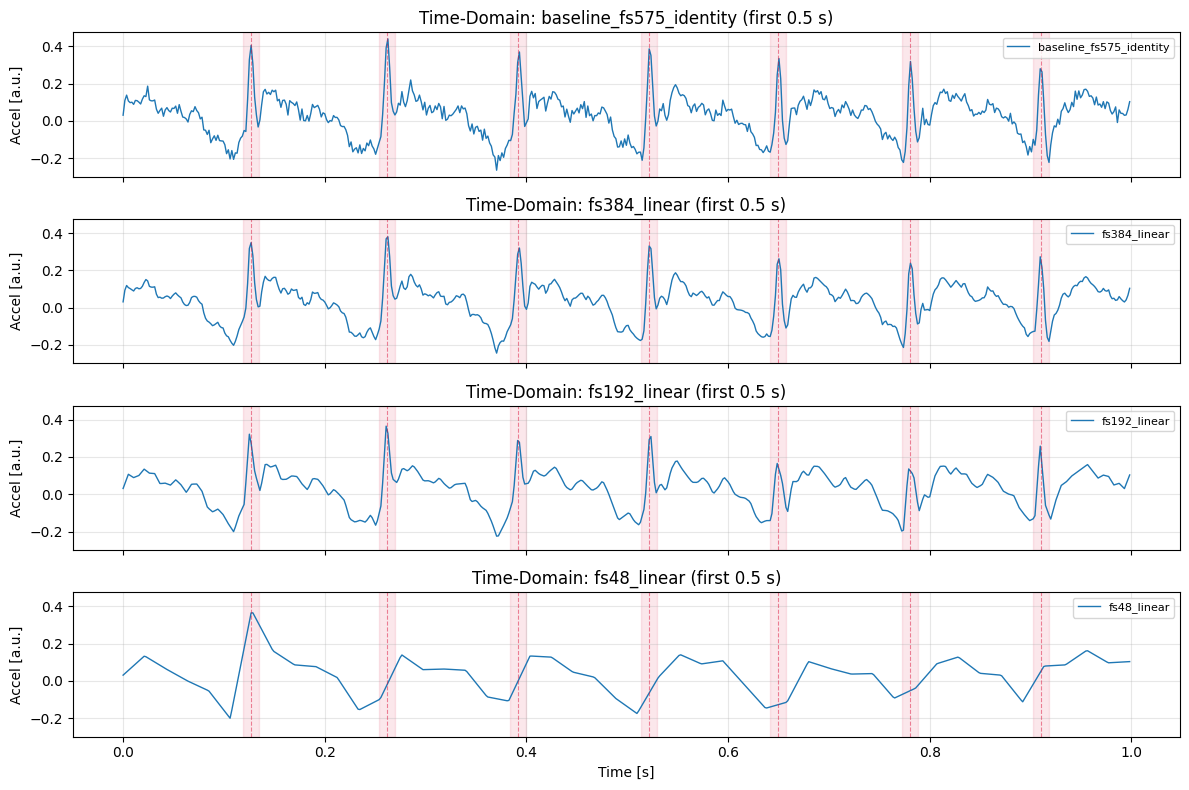

,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct,rmse_abs_increase_vs_baseline
0,baseline_fs575_identity,575,identity,0.000000,1.000000,0.000000,0.000000
1,fs384_linear,384,linear,0.016308,0.989573,11.934669,0.016308
2,fs192_linear,192,linear,0.031352,0.960029,21.963085,0.031352
3,fs48_linear,48,linear,0.085970,0.651967,62.739712,0.085970


In [52]:
import matplotlib.pyplot as plt


def add_relative_rmse_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    baseline_rmse = float(out.loc[out["config"] == "baseline_fs575_identity", "rmse"].iloc[0])
    out["rmse_abs_increase_vs_baseline"] = out["rmse"] - baseline_rmse
    return out


def plot_time_domain_stack(
    reconstructions_map: dict,
    configs: list[str],
    reference_size: int,
    fs_hz: int,
    defect_times_s: np.ndarray | None = None,
    defect_half_width_s: float = 0.008,
 ) -> None:
    time_s = np.arange(reference_size) / fs_hz
    fig, axes = plt.subplots(len(configs), 1, figsize=(12, 8), sharex=True, sharey=True)

    if len(configs) == 1:
        axes = [axes]

    if defect_times_s is None:
        defect_times_s = np.array([], dtype=np.float64)

    defect_times_in_view = defect_times_s[(defect_times_s >= 0.0) & (defect_times_s <= time_s[-1])]

    for i, cfg in enumerate(configs):
        axes[i].plot(time_s, reconstructions_map[cfg], linewidth=1.0, label=cfg)

        for t_evt in defect_times_in_view:
            axes[i].axvspan(
                max(0.0, t_evt - defect_half_width_s),
                min(time_s[-1], t_evt + defect_half_width_s),
                color="crimson",
                alpha=0.10,
            )
            axes[i].axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.5)

        axes[i].set_ylabel("Accel [a.u.]")
        axes[i].set_title("Time-Domain: " + cfg + " (first 0.5 s)")
        axes[i].grid(alpha=0.3)
        axes[i].legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


results_eval_df = add_relative_rmse_columns(results_df)
display_cols = [
    "config",
    "fs_target_hz",
    "method",
    "rmse",
    "corr",
    "spectral_distortion_pct",
    "rmse_abs_increase_vs_baseline",
]

print("Evaluation table (0.5 s window):")
print(results_eval_df[display_cols].to_string(index=False))

plot_configs = ["baseline_fs575_identity", "fs384_linear", "fs192_linear", "fs48_linear"]
defect_times_for_plot = event_times_focus if "event_times_focus" in globals() else np.array([], dtype=np.float64)
plot_time_domain_stack(
    reconstructions,
    plot_configs,
    x_ref.size,
    FS_HZ,
    defect_times_s=defect_times_for_plot,
    defect_half_width_s=EVENT_MARKER_HALF_WIDTH_S, 
)

results_eval_df.sort_values("fs_target_hz", ascending=False)


### Consolidated Evaluation Table (1.0 s window)
| Configuration | fs_target [Hz] | Method | RMSE [a.u.] | Correlation [-] | Spectral Distortion [%] |
|:--|--:|:--|--:|--:|--:|
| baseline_fs575_identity | 575 | identity | 0.000000 | 1.000000 | 0.000000 |
| fs384_linear | 384 | linear | 0.016308 | 0.989573 | 11.934669 |
| fs192_linear | 192 | linear | 0.031352 | 0.960029 | 21.963085 |
| fs48_linear | 48 | linear | 0.085970 | 0.651967 | 62.739712 |


## Day 5 - Analysis and Communication

### Observations

On the extended 1.0 s analysis window containing 7 defect events, RMSE increases from 0.000000 in the 575 Hz baseline to 0.016308 at 384 Hz, 0.031352 at 192 Hz, and 0.085970 at 48 Hz. Correlation decreases from 1.000000 to 0.989573 (384 Hz), 0.960029 (192 Hz), and 0.651967 (48 Hz). Spectral distortion rises from 0.000000% to 11.934669% (384 Hz), 21.963085% (192 Hz), and 62.739712% (48 Hz). Compared to the earlier 0.5 s window (2 events), the 1.0 s window exposes a steeper degradation at 48 Hz — correlation dropped from 0.816 to 0.652 and spectral distortion grew from 55% to 63% — because the broader window captures more of the high-frequency ring-down content that 48 Hz cannot represent. The monotonic degradation trend is preserved across all metrics.


### Interpretation

For synthetic defect-oriented railway monitoring, the 1.0 s-window results with 7 visible defect events confirm that 384 Hz remains a high-fidelity reduced-rate option (RMSE=0.016, corr=0.990, SD=12%). At 192 Hz the signal is still recognisably correct — peaks are preserved and correlation stays above 0.96 — but spectral content is noticeably smoothed (SD=22%). The 48 Hz condition shows severe degradation: correlation collapses to 0.652 and spectral distortion exceeds 62%, meaning individual defect impulses merge into broad, round bumps that are difficult to distinguish from background vibration. The 1.0 s window makes this breakdown more apparent than the previous 0.5 s window, because the Nyquist limit of 24 Hz underrepresents the 95 Hz ring-down component common to all 7 events. In practical terms, 384 Hz offers the best quality-efficiency trade-off, while 48 Hz is insufficient for reliable defect characterisation in this scenario.


### Discussion and Critical Reflection

The updated 1.0 s focus window (7 defect events, starting at t=0) produces consistent and interpretable downsampling behaviour: small degradation at 384 Hz, moderate degradation at 192 Hz, and strong degradation at 48 Hz. The shift from a 0.5 s to a 1.0 s evaluation window increases the sensitivity of the metrics because more periodic defect structure is included — particularly at 48 Hz, where correlation dropped from 0.816 to 0.652. This demonstrates that the choice of analysis window length is itself a methodological parameter: short windows may underestimate degradation if they happen to land on calm segments, while a window that spans a full cycle of expected defect recurrence (T_wheel ≈ 0.130 s → ~7–8 events per second at 80 km/h) provides more representative statistics. At the same time, the synthetic construction imposes known limitations: defect timing, amplitude statistics, and noise are model-driven rather than derived from real field variability. Current conclusions are valid for controlled methodological benchmarking, but should be cross-validated on representative measured data before deployment decisions are made.
